## 📌 개요

본 노트에서는 다양한 자산배분 및 트레이딩 전략을 일관된 방식으로 평가하기 위한  
경량 백테스트 엔진(lightweight backtest engine)을 구현합니다.

이전 노트에서는 개별 전략(정적/동적/ML 리밸런싱)을 각각 구현했다면,  
본 엔진은 전략을 모듈화하여 동일한 시뮬레이션 환경에서 재사용할 수 있도록 설계하는 것을 목표로 합니다.

### 🎯 목표

- Target-weight 기반 포트폴리오 시뮬레이션 엔진 구축
- 거래비용(turnover 기반) 반영
- 전략 교체가 용이한 구조 설계
- 성과 분석 자동화 기반 마련

In [1]:
!pip -q install yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
tickers = ["SPY", "TLT", "GLD"]
start, end = "2020-01-01", "2024-12-31"

prices = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"].dropna()
prices.head()

[*********************100%***********************]  3 of 3 completed


Ticker,GLD,SPY,TLT
Date,,,
2020-01-02,143.949997,297.698914,114.622696
2020-01-03,145.860001,295.444672,116.387924
2020-01-06,147.389999,296.571869,115.727005
2020-01-07,147.970001,295.738068,115.158104
2020-01-08,146.860001,297.314178,114.396828


## 🧠 Backtest Engine 설계

본 엔진은 **target weight 기반 포트폴리오 시뮬레이션**을 중심으로 설계되었습니다.

### 설계 원칙

- 전략과 시뮬레이터의 분리 (Strategy–Engine decoupling)
- 일별 종가 기준(close-to-close) 평가
- 비중 드리프트 자연 반영
- 리밸런싱 시점에만 거래비용 발생
- 다양한 전략으로 확장 가능한 구조

이를 통해 단순 Buy & Hold부터 동적/ML 기반 전략까지  
동일한 프레임워크에서 비교할 수 있도록 합니다.

In [3]:
def run_backtest(
    prices: pd.DataFrame,
    target_weights: pd.DataFrame,
    initial_cash: float = 10_000.0,
    cost_rate: float = 0.001,   # 0.1% per side (simplified)
):
    """
    Target-weight backtest engine (daily close-to-close).
    - prices: DataFrame (index=date, columns=tickers)
    - target_weights: DataFrame (index=date, columns=tickers), rows sum to 1
      * rebalancing occurs on dates where a target row is provided (and not NaN)
    Returns dict with equity, weights, turnover, cost, trades
    """
    prices = prices.sort_index().dropna()
    tickers = list(prices.columns)

    # 타깃 비중 정렬/정합
    tw = target_weights.reindex(prices.index).copy()
    tw = tw[tickers]
    # 리밸런싱 신호: 타깃 행이 존재(결측이 아니고 합이 0이 아님)
    rebalance_flag = tw.notna().all(axis=1)

    # 초기 비중: 첫 리밸런싱 날의 비중을 사용 (없으면 동일가중)
    first_rebal_date = tw.index[rebalance_flag][0] if rebalance_flag.any() else prices.index[0]
    init_w = tw.loc[first_rebal_date] if rebalance_flag.any() else pd.Series(1/len(tickers), index=tickers)
    init_w = init_w / init_w.sum()

    # 상태 변수
    equity = pd.Series(index=prices.index, dtype=float)
    equity.iloc[0] = float(initial_cash)

    w = init_w.astype(float).copy()
    w_hist = pd.DataFrame(index=prices.index, columns=tickers, dtype=float)
    w_hist.iloc[0] = w.values

    turnover = pd.Series(0.0, index=prices.index)
    cost = pd.Series(0.0, index=prices.index)
    trades = []  # list of dict logs

    # 일간 수익률
    rets = prices.pct_change().fillna(0.0)

    for i in range(1, len(prices.index)):
        d = prices.index[i]

        # 1) 전일 비중으로 당일 수익 반영
        r = rets.iloc[i]
        equity.iloc[i] = equity.iloc[i-1] * (1.0 + (w * r).sum())

        # 2) 비중 드리프트 반영
        gross = w * (1.0 + r)
        w = gross / gross.sum()

        # 3) 리밸런싱(타깃이 있는 날)
        if rebalance_flag.iloc[i]:
            target = tw.iloc[i].astype(float)
            target = target / target.sum()

            to = (w - target).abs().sum()              # L1 turnover
            c = to * cost_rate * equity.iloc[i]        # simplified cost

            equity.iloc[i] -= c
            w = target.copy()

            turnover.iloc[i] = to
            cost.iloc[i] = c

            trades.append({
                "date": d,
                "turnover": float(to),
                "cost": float(c),
                "equity_after_cost": float(equity.iloc[i]),
            })

        w_hist.iloc[i] = w.values

    return {
        "equity": equity,
        "weights": w_hist,
        "turnover": turnover,
        "cost": cost,
        "trades": pd.DataFrame(trades),
    }

In [4]:
def strategy_buy_hold(prices: pd.DataFrame, weights: dict):
    idx = prices.index
    tw = pd.DataFrame(index=idx, columns=prices.columns, dtype=float)
    # 첫 날만 목표 비중을 제공
    tw.iloc[0] = pd.Series(weights)
    return tw

weights = {"SPY":0.6, "TLT":0.3, "GLD":0.1}
tw_bh = strategy_buy_hold(prices, weights)

res_bh = run_backtest(
    prices=prices,
    target_weights=tw_bh,
    initial_cash=10_000.0,
    cost_rate=0.001
)

# 결과 확인
res_bh["equity"].head(),
res_bh["trades"].head()

""


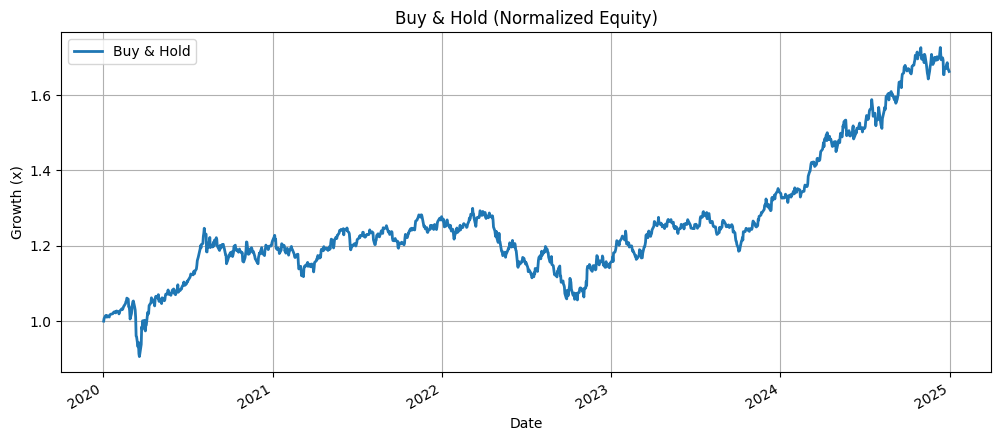

In [5]:
plt.figure(figsize=(12,5))
(res_bh["equity"] / res_bh["equity"].iloc[0]).plot(label="Buy & Hold", linewidth=2)
plt.title("Buy & Hold (Normalized Equity)")
plt.ylabel("Growth (x)")
plt.grid(True)
plt.legend()
plt.show()

### 🔎 결과 해석

Buy & Hold 전략은 초기 목표 비중을 설정한 이후 추가적인 리밸런싱 없이
자산 가격 변동에 따라 비중이 자연스럽게 드리프트되는 구조를 보입니다.

본 결과는 백테스트 엔진이 다음을 정상적으로 수행함을 확인시켜 줍니다:

- 일별 수익률 반영
- 포트폴리오 가치 누적 계산
- 비중 드리프트 처리
- 불필요한 거래 미발생

이는 이후 리밸런싱 전략을 연결하기 위한 기준선(baseline)으로 활용됩니다.

## 🎯 Annual Rebalancing 전략 연결

앞서 구축한 `run_backtest` 엔진에
연 1회 리밸런싱 전략을 연결합니다.

### 전략 개요
- 목표 비중: SPY 60% / TLT 30% / GLD 10%
- 리밸런싱 주기: 매년 첫 거래일
- 그 외 기간: Buy & Hold 유지

이 단계의 목적은 **백테스트 엔진이 다양한 전략을
유연하게 처리할 수 있는지 검증**하는 것입니다.

In [6]:
def annual_rebalance_weights(prices, weights):
  """
  매년 첫 거래일에만 목표 비중으로 리밸런싱
  나머지 날짜는 None 반환 (리밸런싱 없음)
  """
  target = pd.DataFrame(index=prices.index, columns=prices.columns)

  last_year = None
  for dt in prices.index:
    if last_year != dt.year:
      # 새해 첫 거래일 -> 리밸런싱
      target.loc[dt] = pd.Series(weights)
      last_year = dt.year
    else:
      target.loc[dt] = None

  return target

In [7]:
# 목표 비중
tw_annual = annual_rebalance_weights(
    prices=prices,
    weights={'SPY': 0.6, 'TLT': 0.3, 'GLD': 0.1}
)

# 백테스트 실행
res_annual = run_backtest(
    prices=prices,
    target_weights=tw_annual,
    initial_cash=10_000.0,
    cost_rate=0.001
)

# 결과 확인
res_annual["equity"].head()

,0
Date,
2020-01-02,10000.000000
2020-01-03,10014.036210
2020-01-06,10030.084970
2020-01-07,10002.419486
2020-01-08,10006.549589


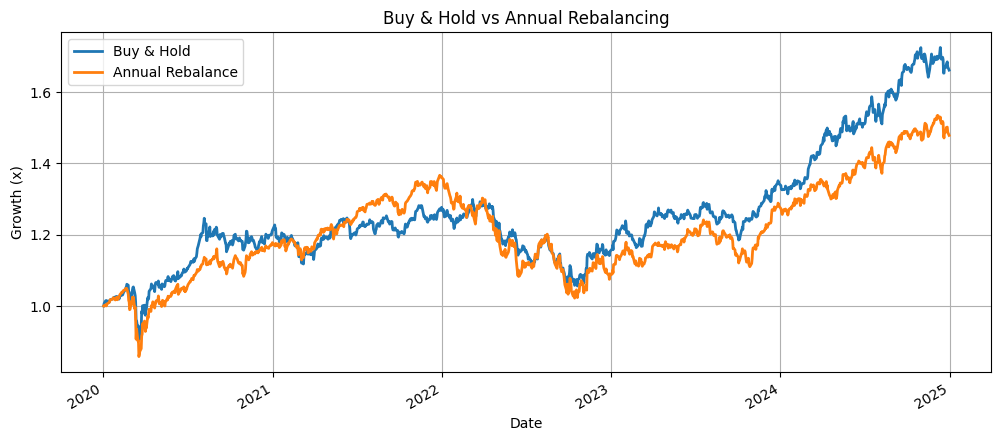

In [8]:
plt.figure(figsize=(12,5))

(res_bh["equity"] / res_bh["equity"].iloc[0]).plot(label="Buy & Hold", linewidth=2)
(res_annual["equity"] / res_annual["equity"].iloc[0]).plot(label="Annual Rebalance", linewidth=2)

plt.title("Buy & Hold vs Annual Rebalancing")
plt.ylabel("Growth (x)")
plt.grid(True)
plt.legend()
plt.show()

### 🔎 결과 해석

Annual Rebalancing 전략은 매년 첫 거래일에 포트폴리오를
목표 비중(SPY 60%, TLT 30%, GLD 10%)으로 다시 맞추는 방식입니다.

이 전략은 자산 가격 변동으로 인해 발생하는 비중 드리프트를 주기적으로 조정함으로써 포트폴리오의 위험 노출을 일정하게 유지하려는 목적을 가집니다.

Buy % Hold 전략과 비교하면 리밸런싱 시점에 거래가 발생하며,
이로 인해 거래비용이 발생할 수 있습니다.

따라서 Annual Rebalancing 전략은
- 포트폴리오 비중 안정성 유지
- 장기 자산배분 전략 유지

라는 장점을 가지지만, 리밸런싱 빈도와 거래비용 사이의 균형을 고려할 필요가 있습니다.

## 🎯 Band Rebalancing 전략 연결

이번에는 포트폴리오 비중이 목표 비중에서 일정 수준 이상 벗어날 때만 리밸런싱을 수행하는 **밴드 리밸런싱 전략**을 엔진에 연결합니다.

### 전략 개요
- 목표 비중: SPY 60% / TLT 30% / GLD 10%
- 리밸런싱 조건: 현재 비중이 목표 비중에서 ±5% 이상 벗어날 경우
- 장점: 불필요한 거래를 줄이고, 거래비용을 절감할 수 있음

이 단계의 목적은 엔진이 **조건 기반 리밸런싱 전략**도 유연하게 처리할 수 있는지 검증하는 것입니다.

In [9]:
def band_rebalance_weights(prices, weights, band=0.05):
  """
  목표 비중에서 일정 밴드 이상 벗어나면 리밸런싱하는 target_weights 생성
  """
  weights_series = pd.Series(weights, dtype=float)
  target = pd.DataFrame(index=prices.index, columns=prices.columns, dtype=float)

  # 초기에는 첫날 목표 비중으로 시작
  current_w = weights_series.copy()
  target.iloc[0] = weights_series

  rets = prices.pct_change().fillna(0.0)

  for i in range(1, len(prices)):
    date = prices.index[i]

    # 하루 수익 반영 후 드리프트된 비중 계산
    gross = current_w * (1.0 + rets.iloc[i])
    current_w = gross / gross.sum()

    # 밴드 초과 여부 확인
    if ((current_w - weights_series).abs() > band).any():
      target.iloc[i] = weights_series
      current_w = weights_series.copy()
    else:
      target.iloc[i] = np.nan

  return target

In [10]:
# ±5% 밴드 전략
tw_band_5 = band_rebalance_weights(
    prices=prices,
    weights={'SPY': 0.6, 'TLT': 0.3, 'GLD': 0.1},
    band=0.05
)

res_band_5 = run_backtest(
    prices=prices,
    target_weights=tw_band_5,
    initial_cash=10_000.0,
    cost_rate=0.001
)

# ±10% 밴드 전략
tw_band_10 = band_rebalance_weights(
    prices=prices,
    weights={'SPY': 0.6, 'TLT': 0.3, 'GLD': 0.1},
    band=0.1
)

res_band_10 = run_backtest(
    prices=prices,
    target_weights=tw_band_10,
    initial_cash=10_000.0,
    cost_rate=0.001
)

# 결과 확인
print("Band 5%")
display(res_band_5["equity"].head())

print("Band 10%")
display(res_band_10["equity"].head())

Band 5%


,0
Date,
2020-01-02,10000.000000
2020-01-03,10072.294806
2020-01-06,10141.659958
2020-01-07,10152.469384
2020-01-08,10115.444644


Band 10%


,0
Date,
2020-01-02,10000.000000
2020-01-03,10072.294806
2020-01-06,10141.659958
2020-01-07,10152.469384
2020-01-08,10115.444644


In [11]:
print("5% band rebalances:", res_band_5["turnover"].gt(0).sum())
print("10% band rebalances:", res_band_10["turnover"].gt(0).sum())

5% band rebalances: 7
10% band rebalances: 3


In [12]:
print("Band 5% final:", res_band_5["equity"].iloc[-1])
print("Band 10% final:", res_band_10["equity"].iloc[-1])

Band 5% final: 16522.238314711263
Band 10% final: 16787.82827882671


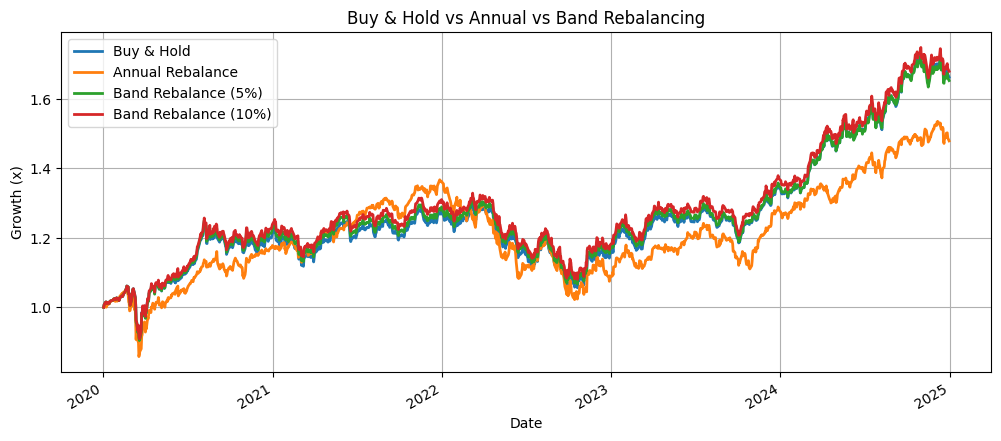

In [13]:
plt.figure(figsize=(12,5))

(res_bh["equity"] / res_bh["equity"].iloc[0]).plot(label="Buy & Hold", linewidth=2)
(res_annual["equity"] / res_annual["equity"].iloc[0]).plot(label="Annual Rebalance", linewidth=2)
(res_band_5["equity"] / res_band_5["equity"].iloc[0]).plot(label="Band Rebalance (5%)", linewidth=2)
(res_band_10["equity"] / res_band_10["equity"].iloc[0]).plot(label="Band Rebalance (10%)", linewidth=2)

plt.title("Buy & Hold vs Annual vs Band Rebalancing")
plt.ylabel("Growth (x)")
plt.grid(True)
plt.legend()
plt.show()

### 🔎 결과 해석

밴드 리밸런싱 전략은 목표 비중에서 일정 수준 이상 벗어났을 때만
리밸런싱을 수행하므로, 연 1회 리밸런싱보다 더 유연한 구조를 가집니다.

- **5% 밴드 전략**은 더 자주 리밸런싱이 발생할 가능성이 높음
- **10% 밴드 전략**은 거래 빈도가 줄어들어 비용 부담이 낮아질 수 있음
- 이를 통해 리밸런싱 빈도와 거래비용 간의 균형을 비교할 수 있음

## 📊 성과지표 계산

백테스트 엔진의 결과를 정량적으로 비교하기 위해 주요 성과지표를 계산합니다.

### 사용 지표
- **CAGR**: 연평균 복리 수익률
- **Sharpe Ratio**: 위험 대비 수익률
- **Max Drawdown**: 최대 낙폭
- **Volatility**: 연환산 변동성

이 단계의 목적은 각 전략의 성과를 동일한 기준으로 비교할 수 있도록 만드는 것입니다.

In [14]:
def calculate_metrics(equity_curve):
  """
  포트폴리오 가치 시계열을 입력받아 주요 성과지표를 계산
  """
  equity_curve = equity_curve.dropna()

  # 일간 수익률
  daily_returns = equity_curve.pct_change().dropna()

  # CAGR
  years = (equity_curve.index[-1] - equity_curve.index[0]).days / 365.25
  cagr = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (1 / years) - 1

  # Volatility
  volatility = daily_returns.std() * np.sqrt(252)

  # Sharpe Ratio (무위험수익률 0 가정)
  sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)

  # Max Drawdown
  running_max = equity_curve.cummax()
  drawdown = equity_curve / running_max - 1
  max_drawdown = drawdown.min()

  return {
      "CAGR": cagr,
      "Volatility": volatility,
      "Sharpe Ratio": sharpe,
      "Max Drawdown": max_drawdown,
  }

In [15]:
metrics_bh = calculate_metrics(res_bh["equity"])
metrics_annual = calculate_metrics(res_annual["equity"])
metrics_band_5 = calculate_metrics(res_band_5["equity"])
metrics_band_10 = calculate_metrics(res_band_10["equity"])

In [16]:
performance_table = pd.DataFrame({
    "Buy & Hold": metrics_bh,
    "Annual Rebalance": metrics_annual,
    "Band Rebalance (5%)": metrics_band_5,
    "Band Rebalance (10%)": metrics_band_10
}).T

performance_table

,CAGR,Volatility,Sharpe Ratio,Max Drawdown
Buy & Hold,0.107041,0.123466,0.887151,-0.186919
Annual Rebalance,0.081471,0.128709,0.674269,-0.252226
Band Rebalance (5%),0.105777,0.124456,0.871867,-0.190877
Band Rebalance (10%),0.109314,0.124139,0.899544,-0.186805


In [17]:
performance_table_style = performance_table.copy()

performance_table_style["CAGR"] = performance_table_style["CAGR"].map(lambda x: f"{x:.2%}")
performance_table_style["Volatility"] = performance_table_style["Volatility"].map(lambda x: f"{x:.2%}")
performance_table_style["Sharpe Ratio"] = performance_table_style["Sharpe Ratio"].map(lambda x: f"{x:.2f}")
performance_table_style["Max Drawdown"] = performance_table_style["Max Drawdown"].map(lambda x: f"{x:.2%}")

performance_table_style

,CAGR,Volatility,Sharpe Ratio,Max Drawdown
Buy & Hold,10.70%,12.35%,0.89,-18.69%
Annual Rebalance,8.15%,12.87%,0.67,-25.22%
Band Rebalance (5%),10.58%,12.45%,0.87,-19.09%
Band Rebalance (10%),10.93%,12.41%,0.90,-18.68%


### 🔎 결과 해석

성과지표를 통해 각 전략의 수익성과 위험을 비교할 수 있습니다.

- **CAGR**이 높을수록 장기 수익률이 우수함
- **Sharpe Ratio**가 높을수록 위험 대비 성과가 우수함
- **Max Drawdown**의 절댓값이 작을수록 최대 손실이 작음을 의미함
- **Volatility**는 전략의 변동성 수준을 나타냄

이를 통해 단순 누적 수익률뿐 아니라 위험 조정 성과까지 함께 평가할 수 있습니다.

## 📊 전략 성과 비교 시각화

여러 리밸런싱 전략의 성과를 직관적으로 비교하기 위해 누적 수익률 곡선을 시각화합니다.

비교 전략:

- Buy & Hold
- Annual Rebalancing
- Band Rebalancing (5%)
- Band Rebalancing (10%)

모든 전략은 동일한 초기 자산과 동일한 거래비용 가정을 사용합니다.

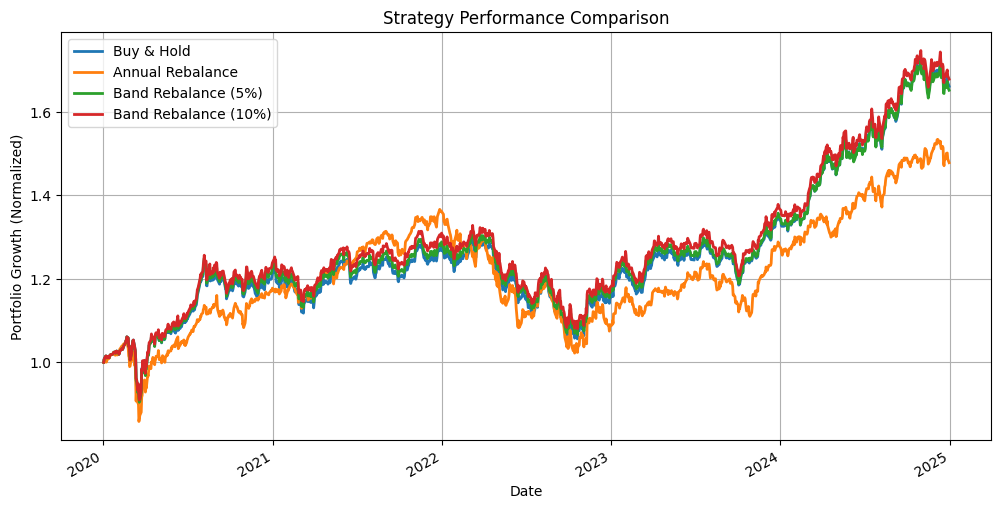

In [18]:
plt.figure(figsize=(12,6))

(res_bh["equity"] / res_bh["equity"].iloc[0]).plot(label="Buy & Hold", linewidth=2)
(res_annual["equity"] / res_annual["equity"].iloc[0]).plot(label="Annual Rebalance", linewidth=2)
(res_band_5["equity"] / res_band_5["equity"].iloc[0]).plot(label="Band Rebalance (5%)", linewidth=2)
(res_band_10["equity"] / res_band_10["equity"].iloc[0]).plot(label="Band Rebalance (10%)", linewidth=2)

plt.title("Strategy Performance Comparison")
plt.ylabel("Portfolio Growth (Normalized)")
plt.xlabel("Date")

plt.legend()
plt.grid(True)
plt.show()

### 🔎 결과 해석

전략 비교 그래프를 통해 각 리밸런싱 전략의 장기 성과를 직관적으로 확인할 수 있습니다.

리밸런싱 전략은 자산 비중이 크게 변화했을 때 포트폴리오를 재조정함으로써 위험을 관리하는 역할을 합니다.

밴드 리밸런싱 전략의 경우 리밸런싱 빈도와 거래비용 사이의 균형에 따라 성과 차이가 발생할 수 있습니다.

이러한 비교를 통해 전략 설계 시 리밸런싱 조건과 거래비용의 영향을 함께 고려할 필요가 있음을 확인할 수 있습니다.

## 📉 Drawdown 비교

단순 수익률 비교만으로는 전략의 위험을 충분히 평가하기 어렵습니다.

따라서 각 전략의 **Drawdown(고점 대비 하락폭)** 을 시각화하여 전략이 어떤 구간에서 얼마나 큰 손실을 경험했는지 비교합니다.

비교 전략:

- Buy & Hold
- Annual Rebalancing
- Band Rebalancing (5%)
- Band Rebalancing (10%)

In [19]:
def calculate_drawdown(equity_curve):
  running_max = equity_curve.cummax()
  drawdown = equity_curve / running_max - 1
  return drawdown

In [20]:
dd_bh = calculate_drawdown(res_bh["equity"])
dd_annual = calculate_drawdown(res_annual["equity"])
dd_band_5 = calculate_drawdown(res_band_5["equity"])
dd_band_10 = calculate_drawdown(res_band_10["equity"])

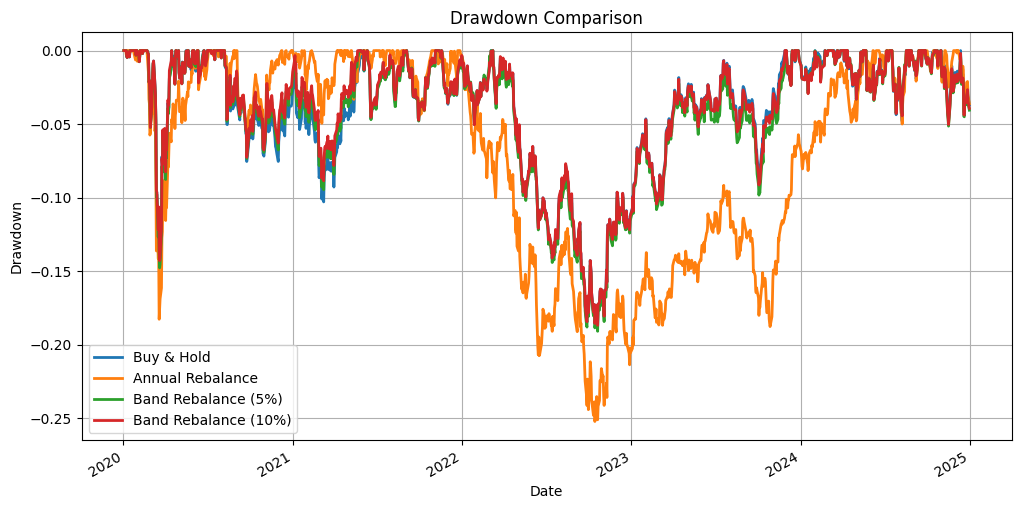

In [21]:
plt.figure(figsize=(12,6))

dd_bh.plot(label="Buy & Hold", linewidth=2)
dd_annual.plot(label="Annual Rebalance", linewidth=2)
dd_band_5.plot(label="Band Rebalance (5%)", linewidth=2)
dd_band_10.plot(label="Band Rebalance (10%)", linewidth=2)

plt.title("Drawdown Comparison")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

### 🔎 결과 해석

Drawdown 그래프를 통해 각 전략이 고점 대비 얼마나 큰 손실을 경험했는지 확인할 수 있습니다.

그래프에서 아래로 크게 내려갈수록 해당 시점에서의 손실 폭이 컸음을 의미합니다.

특히 곡선의 가장 낮은 지점은 해당 전략의 **Max Drawdown**에 해당하며, 값의 절댓값이 작을수록 전략이 경험한 최대 손실이 작았음을 의미합니다.

## 💸 Turnover 및 거래비용 비교

리밸런싱 전략은 거래 빈도에 따라 거래비용이 달라집니다.

따라서 각 전략의 **Turnover(비중 조정 규모)** 와 이에 따른 **누적 거래 비용**을 비교하여 전략의 실질적인 효율성을 평가합니다.

In [22]:
turnover_summary = pd.DataFrame({
    "Buy & Hold": {
        "Total Turnover": res_bh["turnover"].sum(),
        "Total Cost": res_bh["cost"].sum()
    },
    "Annual Rebalance": {
        "Total Turnover": res_annual["turnover"].sum(),
        "Total Cost": res_annual["cost"].sum()
    },
    "Band Rebalance (5%)": {
        "Total Turnover": res_band_5["turnover"].sum(),
        "Total Cost": res_band_5["cost"].sum()
    },
    "Band Rebalance (10%)": {
        "Total Turnover": res_band_10["turnover"].sum(),
        "Total Cost": res_band_10["cost"].sum()
    }
}).T

turnover_summary

,Total Turnover,Total Cost
Buy & Hold,0.000000,0.000000
Annual Rebalance,0.332426,4.233557
Band Rebalance (5%),0.433840,4.898716
Band Rebalance (10%),0.354578,4.064169


In [23]:
turnover_summary_style = turnover_summary.copy()
turnover_summary_style["Total Turnover"] = turnover_summary_style["Total Turnover"].map(lambda x: f"{x:.4f}")
turnover_summary_style["Total Cost"] = turnover_summary_style["Total Cost"].map(lambda x: f"${x:,.2f}")

turnover_summary_style

,Total Turnover,Total Cost
Buy & Hold,0.0000,$0.00
Annual Rebalance,0.3324,$4.23
Band Rebalance (5%),0.4338,$4.90
Band Rebalance (10%),0.3546,$4.06


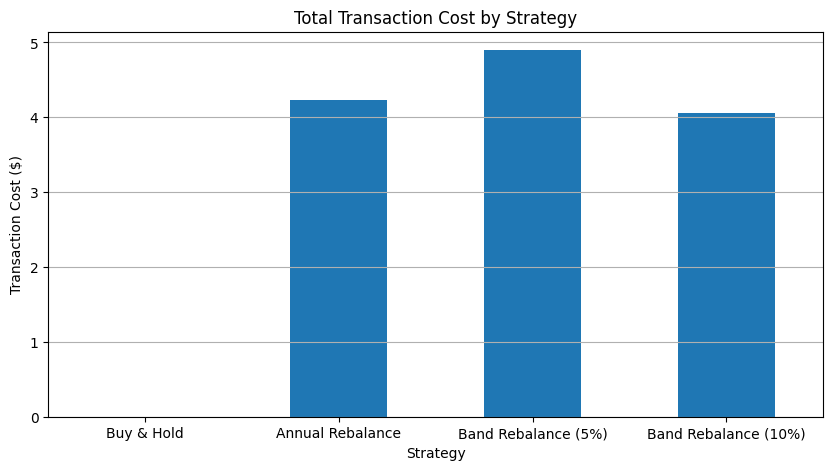

In [24]:
plt.figure(figsize=(10,5))

turnover_summary["Total Cost"].plot(kind="bar")

plt.title("Total Transaction Cost by Strategy")
plt.ylabel("Transaction Cost ($)")
plt.xlabel("Strategy")

plt.xticks(rotation=0)

plt.grid(axis="y")
plt.show()

### 🔎 결과 해석

Turnover와 거래비용 비교를 통해 각 전략이 얼마나 자주, 그리고 얼마나 큰 규모로 리밸런싱을 수행했는지 확인할 수 있습니다.

- Buy & Hold 전략은 리밸런싱이 없기 때문에 거래비용이 거의 발생하지 않음
- Annual Rebalancing 전략은 정기적으로 거래가 발생함
- Band Rebalancing 전략은 밴드 폭에 따라 거래 빈도와 비용이 달라짐
- 일반적으로 밴드가 좁을수록 더 자주 리밸런싱이 발생해 비용이 증가할 가능성이 있음

이를 통해 단순 수익률뿐 아니라 **거래 효율성**까지 함께 평가할 수 있습니다.

## 📌 결론

본 노트에서는 다양한 자산배분 전략을 평가할 수 있는 경량 백테스트 엔진(lightweight backtest engine)을 구축했습니다.

구현된 엔진을 활용하여 다음 전략을 비교했습니다.

- Buy & Hold
- Annual Rebalancing
- Band Rebalancing (5%)
- Band Rebalancing (10%)

분석 결과를 통해 다음과 같은 점을 확인할 수 있습니다.

- 리밸런싱 전략은 포트폴리오 비중을 안정적으로 유지하는 역할을 합니다.
- 밴드 리밸런싱 전략은 리밸런싱 빈도와 거래비용 사이의 균형을 제공합니다.
- 전략 평가는 단순 수익률뿐 아니라 Drawdown 및 거래비용을 함께 고려해야 합니다.

본 백테스트 엔진은 향후 다음과 같은 확장이 가능합니다.

- 동적 리밸런싱 전략 적용
- 머신머닝 기반 트레이딩 전략 연결
- 다양한 자산군 및 전략 테스트

이를 통해 다양한 포트폴리오 전략을 일관된 환경에서 비교·평가할 수 있습니다.